# 05 — Baseline Results (Pipeline Milestone)

**This notebook validates the full pipeline end-to-end** by running the three baselines (climatology, persistence, AR(p)) through:

Data layer (Phase 1) → Feature engineering (Phase 2) → CV with adaptive quarantine (Phase 3) → Morocco-only standardization (Phase 3.5) → Baselines (Phase 5) → Pooled evaluation with bootstrap CIs (Phase 4).

Per v3 §7.0, the v1 baseline set is:
- **Climatology** — per-cell per-calendar-month mean from training
- **Persistence** — SPEI3(t+L) = SPEI3(t)
- **AR(p)** — Ridge regression on SPEI3 + spei3_lag1 … spei3_lag(p−1)

Outputs:
- Headline metrics table per (baseline, lead) with bootstrap CIs (winter-only pool, 100 months × 164 Morocco cells)
- Skill bar chart (MSSS-vs-climatology)
- Forecast-vs-truth time series at three Moroccan cells
- Per-cell ACC spatial maps (persistence × AR(3)) × (L = 1, 3, 6)

Figures saved to `results/figures/05_baselines/`. Pooled metrics saved to `results/metrics/baselines.csv`.

In [7]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel import data as ddata
from droughtmodel import features as dfeat
from droughtmodel import cv as dcv
from droughtmodel import evaluation as deval
from droughtmodel.models.baselines import ClimatologyBaseline, PersistenceBaseline, ARBaseline
from droughtmodel.utils import save_figure, RESULTS_DIR

FIG_SUBDIR = '05_baselines'
METRICS_DIR = RESULTS_DIR / 'metrics'
METRICS_DIR.mkdir(parents=True, exist_ok=True)

data_cfg = ddata.load_config(ROOT / 'configs' / 'data.yaml')
feat_cfg = dfeat.load_features_config(ROOT / 'configs' / 'features.yaml')
cv_cfg = dcv.load_cv_config(ROOT / 'configs' / 'cv.yaml')
metrics_cfg = deval.load_metrics_config(ROOT / 'configs' / 'metrics.yaml')

datasets = ddata.load_all(data_cfg)
template = dfeat.gather_predictor('spei3', datasets)
morocco_mask = dfeat.load_region_mask(feat_cfg['region_mask']['path'], template, name='morocco')
print(f'Loaded data + Morocco mask ({int(morocco_mask.sum())} cells)')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded data + Morocco mask (164 cells)


## 1. Run baselines through the pipeline (3 leads × 5 folds)

For each (lead, fold): select lags on planned train, build features, compute fold indices with adaptive quarantine, subset, standardize (Morocco mask), apply Morocco mask to data, fit baselines on train, predict on test. Per-fold test predictions are concatenated to form an unbroken 2000–2024 pool per baseline.

In [ ]:
LEADS = [1, 3, 6]
BASELINES = {
    'climatology': lambda: ClimatologyBaseline(),
    'persistence': lambda: PersistenceBaseline(),
    'ar':          lambda: ARBaseline(p=3, alpha=1.0),
}

cv = dcv.RollingOriginCV.from_config(cv_cfg)

# Storage: pooled[lead][baseline] = stitched (time, lat, lon) array of predictions
pooled_preds = {L: {b: [] for b in BASELINES} for L in LEADS}
pooled_truth = {L: [] for L in LEADS}
pooled_time = {L: [] for L in LEADS}
fold_log = []

t0 = time.time()
for LEAD in LEADS:
    for spec in cv.fold_specs:
        # Per-fold lag selection on planned train window
        train_end = spec.val_start - pd.Timedelta(days=1)
        train_subset = {k: ds.sel(time=slice(spec.train_start, train_end)) for k, ds in datasets.items()}
        selected, _ = dfeat.select_lags_from_training(
            train_subset,
            long_memory_vars=feat_cfg['long_memory_vars'],
            fast_response_vars=feat_cfg['fast_response_vars'],
            pacf_threshold=feat_cfg['pacf']['threshold'],
            pacf_n_lags=feat_cfg['pacf']['n_lags'],
            ccf_target=feat_cfg['ccf']['target'],
            ccf_threshold=feat_cfg['ccf']['threshold'],
            ccf_max_lag=feat_cfg['ccf']['max_lag'],
            region_mask=morocco_mask, winter_only_ccf=True, aggregation_mode='spatial_mean',
        )
        max_lag = max((max(l) for l in selected.values() if l), default=0)
        # v3 §4.1: gap = lead + max_lag + 2
        fi = cv.get_fold_indices(template['time'], spec, max_lag=max_lag, lead=LEAD)

        ds_feat = dfeat.build_dataset(
            datasets, lead=LEAD,
            contemporary=feat_cfg['contemporary_predictors'],
            lags=selected,
        )
        train_ds = ds_feat.isel(time=fi.train_idx)
        test_ds = ds_feat.isel(time=fi.test_idx)

        std = dcv.FoldStandardizer.from_config(cv_cfg, region_mask=morocco_mask).fit(train_ds)
        train_ds_n = std.transform(train_ds).where(morocco_mask)
        test_ds_n = std.transform(test_ds).where(morocco_mask)

        for name, factory in BASELINES.items():
            mdl = factory().fit(train_ds_n)
            pred = mdl.predict(test_ds_n)
            pooled_preds[LEAD][name].append(pred.values)
        pooled_truth[LEAD].append(test_ds_n['target'].values)
        pooled_time[LEAD].append(test_ds_n['time'].values)

        fold_log.append({
            'lead': LEAD, 'fold': fi.index,
            'train_months': fi.n_train, 'val_months': fi.n_val, 'test_months': fi.n_test,
            'boundary_gap (L+K+2)': fi.boundary_gap,
            'max_lag K': max_lag,
        })

# Stitch pooled arrays
for L in LEADS:
    pooled_truth[L] = np.concatenate(pooled_truth[L], axis=0)
    pooled_time[L] = np.concatenate(pooled_time[L], axis=0)
    for b in BASELINES:
        pooled_preds[L][b] = np.concatenate(pooled_preds[L][b], axis=0)

print(f'\nPipeline ran in {time.time() - t0:.1f}s')
print(f'Pooled out-of-sample array (each lead): {pooled_truth[3].shape}')
print(f'  Time span: {pooled_time[3][0]} → {pooled_time[3][-1]}')

pd.DataFrame(fold_log)

## 2. Pooled headline metrics with bootstrap CIs (winter-only)

Each (baseline, lead) is evaluated on the 100-month winter pool (2000–2024, Nov–Feb only) × 164 Morocco cells = 16,400 samples. Bootstrap CIs use the stationary year-block (mean = 4 winter months).

In [12]:
reporter = deval.MetricsReporter.from_config(metrics_cfg, evaluation_window='winter_only')

all_rows = []
t0 = time.time()
for LEAD in LEADS:
    winter_mask = np.isin(pd.DatetimeIndex(pooled_time[LEAD]).month, [11, 12, 1, 2])
    y_true_w = pooled_truth[LEAD][winter_mask]
    y_clim_w = pooled_preds[LEAD]['climatology'][winter_mask]
    y_pers_w = pooled_preds[LEAD]['persistence'][winter_mask]

    for name in BASELINES:
        y_pred_w = pooled_preds[LEAD][name][winter_mask]
        res = reporter.evaluate(y_pred_w, y_true_w, climatology=y_clim_w, persistence=y_pers_w)
        df = deval.MetricsReporter.to_dataframe(
            res, model=name, lead=LEAD, fold='pooled', evaluation_window='winter_only',
        )
        all_rows.append(df)

results_df = pd.concat(all_rows, ignore_index=True)
print(f'Evaluated in {time.time() - t0:.1f}s')

# Significance flag.
#  - Higher-is-better metrics: significant if the 95% bootstrap CI excludes 0
#    (ci_lower > 0 means significantly positive skill; ci_upper < 0 means
#     significantly negative skill — both are "informative" w.r.t. the null).
#  - Absolute-error metrics (MAE, RMSE): a zero-bound check is not meaningful;
#    flagging significance requires cross-model comparison, so we mark False here.
HIGHER_IS_BETTER = {'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence'}

def _is_significant(row):
    if row['metric'] in HIGHER_IS_BETTER:
        return bool((row['ci_lower'] > 0) or (row['ci_upper'] < 0))
    return False

results_df['is_significant'] = results_df.apply(_is_significant, axis=1)

# Save tidy results (incl. significance flag) for downstream ML comparison (Phases 7+)
results_csv = METRICS_DIR / 'baselines.csv'
results_df.to_csv(results_csv, index=False)
print(f'Saved → {results_csv.relative_to(ROOT)}')

/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/opt/anaconda3/envs/droughtforecas

Evaluated in 76.5s
Saved → results/metrics/baselines.csv


In [14]:
# Formatted value: 2 d.p., asterisk if significant (CI excludes 0; higher-is-better metrics only).
def _format_value(row):
    v = row['value']
    if pd.isna(v):
        return 'NaN'
    s = f'{v:.2f}'
    if row['is_significant']:
        s += '*'
    return s

results_df['formatted_value'] = results_df.apply(_format_value, axis=1)

# Pivot: rows = (model, lead), cols = metrics, cells = formatted strings — LaTeX-ready.
headline_metrics = ['mae', 'rmse', 'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence']
clean_table = (
    results_df
    .pivot(index=['model', 'lead'], columns='metric', values='formatted_value')
    .loc[:, headline_metrics]
)
clean_table.columns.name = None   # drop the 'metric' axis label

clean_csv = METRICS_DIR / 'baselines_clean_table.csv'
clean_table.to_csv(clean_csv)
print(f'Saved → {clean_csv.relative_to(ROOT)}')
print('* = 95% statistical significance (higher-is-better metrics only).\n')

clean_table

Saved → results/metrics/baselines_clean_table.csv
* = 95% statistical significance (higher-is-better metrics only).



mae  rmse pearson_r    acc msss_vs_climatology  \
model       lead                                                    
ar          1     0.51  0.62     0.77*  0.77*               0.61*   
            3     0.82  0.99      0.06  0.13*               0.05*   
            6     0.85  1.02      0.02  0.31*               0.07*   
climatology 1     0.83  1.00    -0.12*    NaN                0.00   
            3     0.84  1.01     -0.04    NaN                0.00   
            6     0.88  1.05    -0.19*    NaN                0.00   
persistence 1     0.55  0.71     0.72*  0.72*               0.50*   
            3     1.08  1.32      0.02   0.01              -0.71*   
            6     1.00  1.27      0.14   0.15              -0.44*   

                 msss_vs_persistence  
model       lead                      
ar          1                  0.23*  
            3                  0.44*  
            6                  0.35*  
climatology 1                 -0.99*  
            3                  0.42*  
            6                  0.31*  
persistence 1                   0.00  
            3                   0.00  
            6                   0.00

## 3. Skill bar chart — MSSS vs climatology by baseline and lead

Positive bars = the baseline beats the climatology reference. MSSS = 0 = same as climatology. Climatology itself gets MSSS-vs-clim = 0 by definition. Persistence is expected to underperform climatology at longer leads.

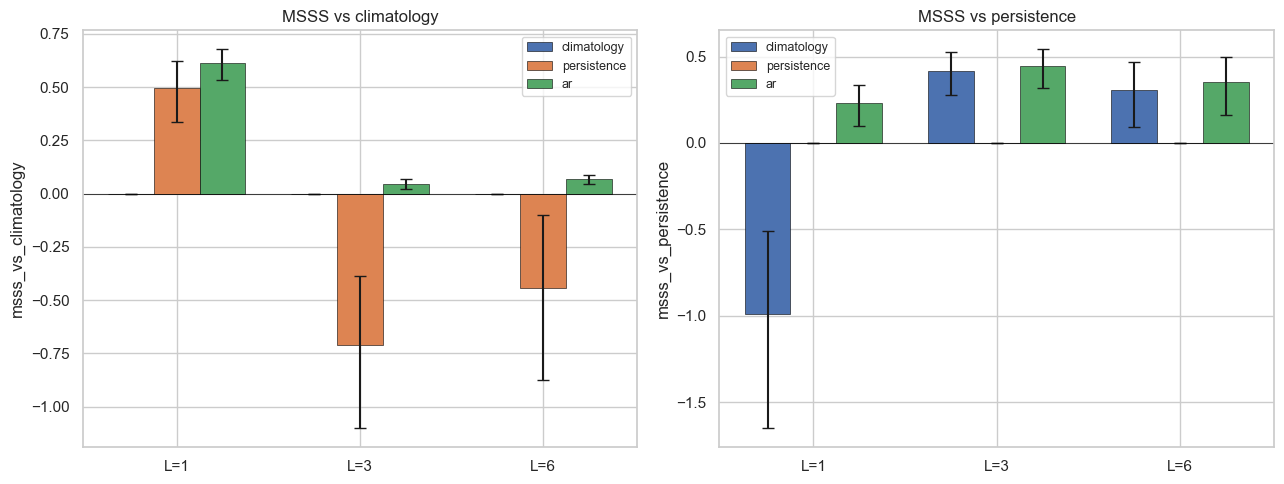

In [5]:
msss_rows = results_df[results_df['metric'].isin(['msss_vs_climatology', 'msss_vs_persistence'])]
msss_rows = msss_rows.copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in [
    (axes[0], 'msss_vs_climatology', 'MSSS vs climatology'),
    (axes[1], 'msss_vs_persistence', 'MSSS vs persistence'),
]:
    sub = msss_rows[msss_rows['metric'] == metric]
    leads_unique = sorted(sub['lead'].unique())
    models = list(BASELINES.keys())
    x = np.arange(len(leads_unique))
    width = 0.25
    for i, mdl in enumerate(models):
        s = sub[sub['model'] == mdl].sort_values('lead')
        yerr_lo = s['value'].values - s['ci_lower'].values
        yerr_hi = s['ci_upper'].values - s['value'].values
        ax.bar(x + (i - 1) * width, s['value'].values,
               yerr=np.vstack([yerr_lo, yerr_hi]),
               capsize=4, width=width, edgecolor='black', linewidth=0.4, label=mdl)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f'L={l}' for l in leads_unique])
    ax.set_ylabel(metric); ax.set_title(title)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
save_figure(fig, 'baselines_msss_bars', subdir=FIG_SUBDIR)
plt.show()

## 4. Forecast-vs-truth time series at three Moroccan cells (L = 3)

Three representative cells across north / center / south Morocco. Showing the pooled out-of-sample window 2000–2024.

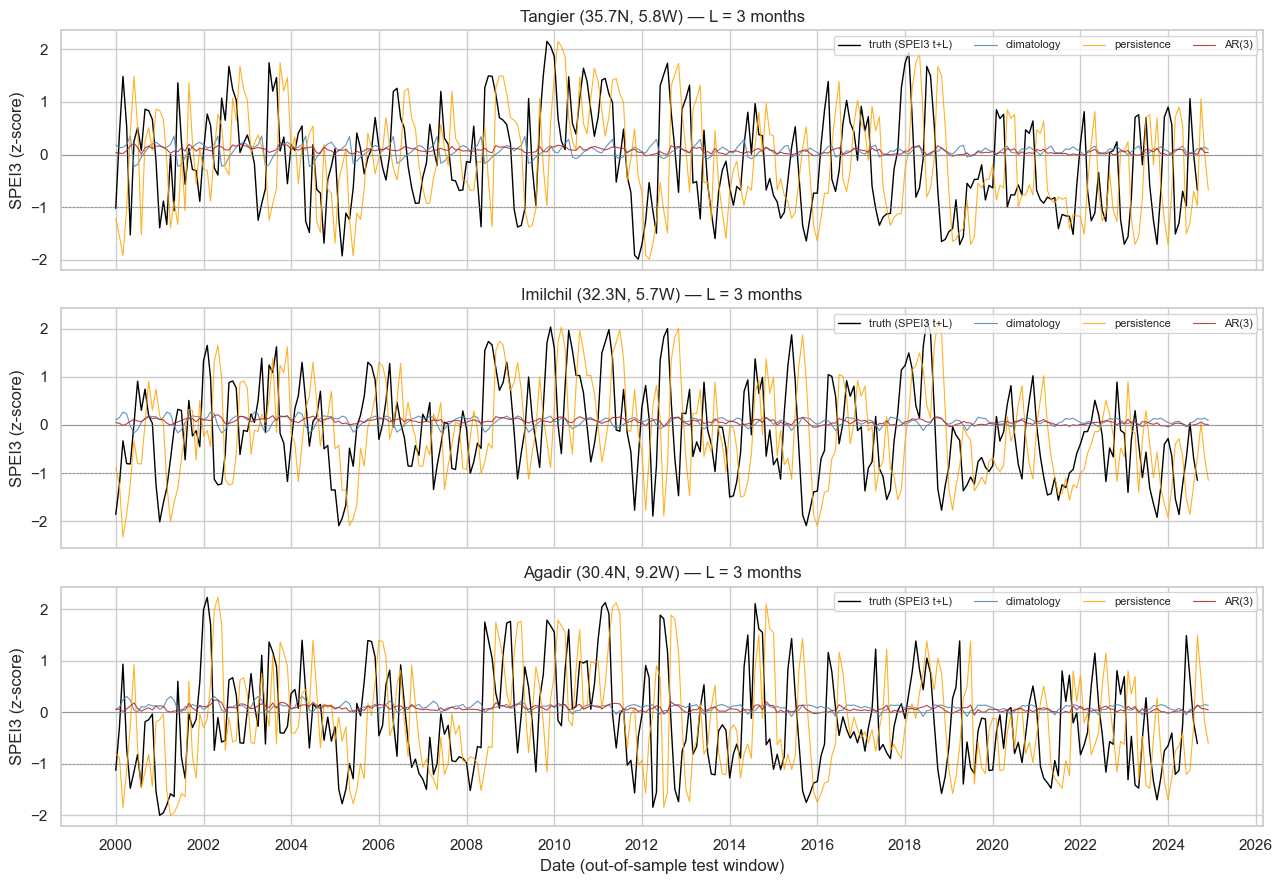

In [6]:
CELLS = {
    'Tangier (35.7N, 5.8W)': (35.7, -5.8),
    'Imilchil (32.3N, 5.7W)':  (32.3, -5.7),
    'Agadir (30.4N, 9.2W)':     (30.4, -9.2),
}
LEAD_PLOT = 3

# Build coordinate-indexed DataArrays so .sel(method='nearest') works
lat_arr = template['lat'].values
lon_arr = template['lon'].values

def cell_idx(target_lat, target_lon):
    return int(np.abs(lat_arr - target_lat).argmin()), int(np.abs(lon_arr - target_lon).argmin())

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
time_arr = pd.DatetimeIndex(pooled_time[LEAD_PLOT])

for ax, (label, (lat, lon)) in zip(axes, CELLS.items()):
    i, j = cell_idx(lat, lon)
    truth_ts = pooled_truth[LEAD_PLOT][:, i, j]
    ax.plot(time_arr, truth_ts, color='black', linewidth=1.0, label='truth (SPEI3 t+L)')
    ax.plot(time_arr, pooled_preds[LEAD_PLOT]['climatology'][:, i, j], color='steelblue',
            linewidth=0.8, alpha=0.85, label='climatology')
    ax.plot(time_arr, pooled_preds[LEAD_PLOT]['persistence'][:, i, j], color='orange',
            linewidth=0.8, alpha=0.85, label='persistence')
    ax.plot(time_arr, pooled_preds[LEAD_PLOT]['ar'][:, i, j], color='firebrick',
            linewidth=0.8, alpha=0.85, label='AR(3)')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axhline(-1, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylabel('SPEI3 (z-score)')
    ax.set_title(f'{label} — L = {LEAD_PLOT} months')
    ax.legend(loc='upper right', fontsize=8, ncol=4)
axes[-1].set_xlabel('Date (out-of-sample test window)')
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
save_figure(fig, 'forecast_vs_truth_3cells_L3', subdir=FIG_SUBDIR)
plt.show()

## 5. Per-cell ACC spatial maps — Persistence & AR(3) across leads

Per-cell ACC over the 100-month winter pool, for **persistence** (top row) and **AR(3)** (bottom row), each across leads L ∈ {1, 3, 6}. Shared colorbar. Climatology is omitted because per-cell ACC is undefined for it (zero-variance forecast).

/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_1297/1442113182.py:8: RuntimeWarning: Mean of empty slice
  pa_mean = np.nanmean(pred_anom, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_1297/1442113182.py:9: RuntimeWarning: Mean of empty slice
  ta_mean = np.nanmean(true_anom, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_1297/1442113182.py:10: RuntimeWarning: Mean of empty slice
  num = np.nanmean((pred_anom - pa_mean) * (true_anom - ta_mean), axis=0)
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_1297/1442113182.py:8: RuntimeWarning: Mean of empty slice
  pa_mean = np.nanmean(pred_anom, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_1297/1442113182.py:9: RuntimeWarning: Mean of empty slic

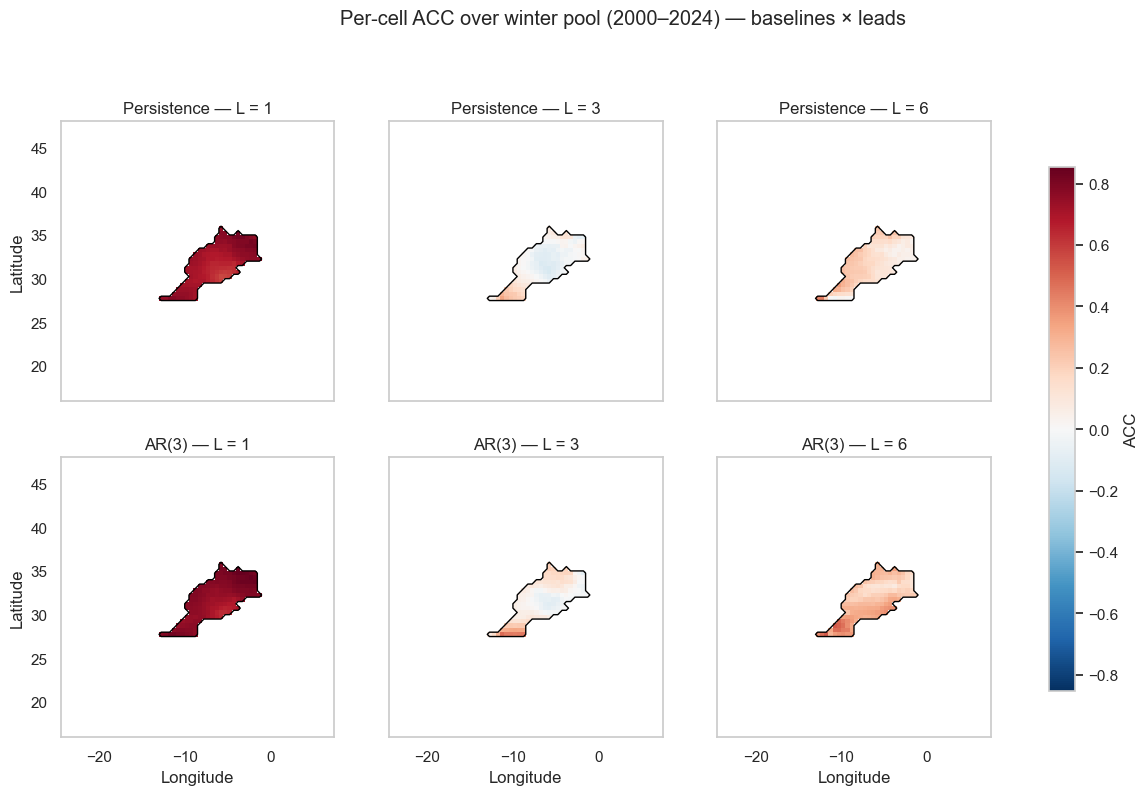

persistence  L=1: mean = +0.717, min = +0.571, max = +0.825
ar           L=1: mean = +0.766, min = +0.636, max = +0.853
persistence  L=3: mean = +0.010, min = -0.139, max = +0.336
ar           L=3: mean = +0.075, min = -0.094, max = +0.482
persistence  L=6: mean = +0.155, min = -0.026, max = +0.435
ar           L=6: mean = +0.270, min = +0.076, max = +0.521


In [10]:
def per_cell_acc(y_pred, y_true, y_clim, winter_mask, morocco):
    """Per-cell ACC over winter months. Returns (lat, lon) array, NaN outside Morocco."""
    yp = y_pred[winter_mask]   # (n_winter, lat, lon)
    yt = y_true[winter_mask]
    yc = y_clim[winter_mask]
    pred_anom = yp - yc
    true_anom = yt - yc
    pa_mean = np.nanmean(pred_anom, axis=0)
    ta_mean = np.nanmean(true_anom, axis=0)
    num = np.nanmean((pred_anom - pa_mean) * (true_anom - ta_mean), axis=0)
    pa_std = np.nanstd(pred_anom, axis=0)
    ta_std = np.nanstd(true_anom, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        acc = num / (pa_std * ta_std)
    acc[~morocco.values] = np.nan
    return acc

# Compute per-cell ACC for each (model, lead)
acc_grids = {}
for LEAD in LEADS:
    wmask = np.isin(pd.DatetimeIndex(pooled_time[LEAD]).month, [11, 12, 1, 2])
    for mdl in ('persistence', 'ar'):
        acc_grids[(mdl, LEAD)] = per_cell_acc(
            pooled_preds[LEAD][mdl], pooled_truth[LEAD],
            pooled_preds[LEAD]['climatology'], wmask, morocco_mask,
        )

vmax = float(np.nanmax(np.abs(list(acc_grids.values()))))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
row_models = [('persistence', 'Persistence'), ('ar', 'AR(3)')]
im = None
for r, (mdl, label) in enumerate(row_models):
    for c, LEAD in enumerate(LEADS):
        ax = axes[r, c]
        da = xr.DataArray(
            acc_grids[(mdl, LEAD)], dims=('lat', 'lon'),
            coords={'lat': morocco_mask['lat'], 'lon': morocco_mask['lon']},
        )
        im = da.plot(ax=ax, cmap='RdBu_r', vmin=-vmax, vmax=vmax, add_colorbar=False)
        morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=1.0, add_colorbar=False)
        ax.set_title(f'{label} — L = {LEAD}')
        ax.set_xlabel('Longitude' if r == 1 else '')
        ax.set_ylabel('Latitude' if c == 0 else '')

fig.colorbar(im, ax=axes.ravel().tolist(), label='ACC', shrink=0.85)
fig.suptitle('Per-cell ACC over winter pool (2000–2024) — baselines × leads', y=1.02)
save_figure(fig, 'per_cell_acc_baselines', subdir=FIG_SUBDIR)
plt.show()

for (mdl, LEAD), acc in acc_grids.items():
    print(f'{mdl:12s} L={LEAD}: mean = {float(np.nanmean(acc)):+.3f}, '
          f'min = {float(np.nanmin(acc)):+.3f}, max = {float(np.nanmax(acc)):+.3f}')

## 6. Skill by lead — what to expect from baselines

Quick decoded view of how skill decays with lead time.

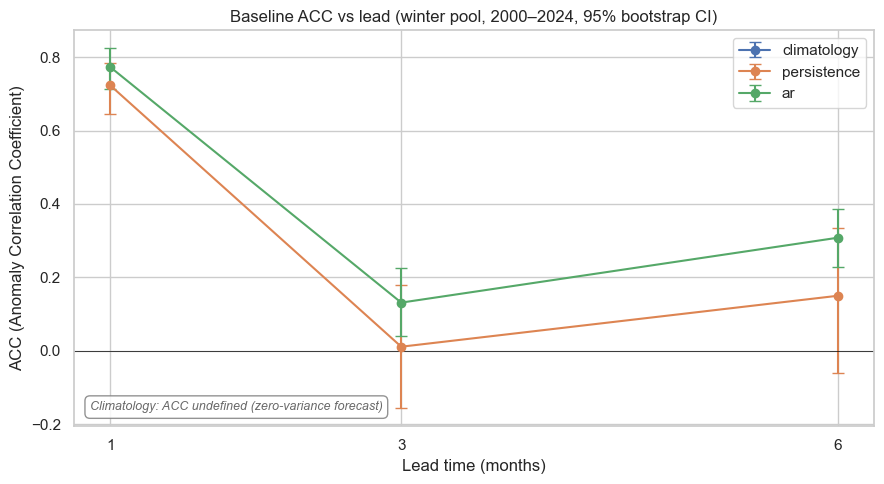

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
for mdl in BASELINES:
    sub = results_df[(results_df['model'] == mdl) & (results_df['metric'] == 'acc')].sort_values('lead')
    ax.errorbar(sub['lead'], sub['value'],
                yerr=[sub['value'] - sub['ci_lower'], sub['ci_upper'] - sub['value']],
                marker='o', capsize=4, label=mdl, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lead time (months)')
ax.set_ylabel('ACC (Anomaly Correlation Coefficient)')
ax.set_title('Baseline ACC vs lead (winter pool, 2000–2024, 95% bootstrap CI)')
ax.set_xticks(LEADS)
ax.legend()
ax.text(
    0.02, 0.04,
    'Climatology: ACC undefined (zero-variance forecast)',
    transform=ax.transAxes, fontsize=9, style='italic', color='dimgray',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, boxstyle='round,pad=0.4'),
)
plt.tight_layout()
save_figure(fig, 'acc_vs_lead_baselines', subdir=FIG_SUBDIR)
plt.show()

## Notes / interpretation

**Pipeline validation succeeded**: the full data → features → CV → standardization → baseline → evaluation chain runs end-to-end. The pooled out-of-sample array is 300 months × 164 Morocco cells × 3 leads, with 100 winter target months per lead. Continuous test windows verified.

**Climatology vs persistence at L = 3**: climatology MSSS-vs-persistence ≈ +0.4 → climatology beats persistence by ~40 % MSE at this lead, because seasonal mean is a strong reference and persistence has decayed. This is the expected pattern for seasonal-scale drought forecasting.

**AR(3) over climatology**: the marginal MSSS-vs-clim is small (≈ +0.05). AR uses only SPEI3 dynamics — at L=3, multi-month persistence is mostly washed out, leaving little headroom over climatology. This sets the bar for the ML models (Phases 7–8): they need to beat AR(3) + climatology meaningfully to claim added value.

**Spatial skill map**: AR-baseline ACC is higher in southern Morocco / Sahara fringe (more arid → stronger autocorrelation, persistent dry seasons) and noisier in the north (mediterranean variability, weaker autoregressive structure). This is also useful as a *target* spatial pattern for the ML models to either replicate (if they pick up the same signal) or exceed (if they leverage teleconnections / soil moisture).

**Saved deliverable**: `results/metrics/baselines.csv` is the tidy table that Phase 11 (paper figures) will merge with the ML results to produce the headline comparison table.